# DL Competition 01 — Image Classification (PyTorch)
**Intel Scene Classification — 6 Classes**

**Approach: Deep MLP with Residual Connections**

### Architecture highlights:
1. **Deep MLP** with residual (skip) connections to enable deeper training
2. **RGB images** (3 channels) retain color info critical for scene classification
3. **BatchNorm + Dropout + Weight Decay** for strong regularization
4. **GELU activations** — smoother than ReLU, better gradient flow
5. **Aggressive data augmentation** to compensate for lack of spatial inductive bias
6. **Full validation set** (~2,400 samples) with stratified split
7. **Learning rate scheduling + early stopping** for optimal convergence
8. **Mixup training** for additional regularization and better generalization


## Step 0: Imports and Setup

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Subset, Dataset
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
import pandas as pd
from tqdm import tqdm
import copy

print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

# Device setup — use GPU if available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
if device == 'cuda':
    torch.cuda.manual_seed_all(42)


CUDA available: True
CUDA version: 12.6
GPU count: 2
Using device: cuda


## Step 1: Data Loading and Preprocessing

### Preprocessing Strategy
- **RGB (3 channels)** — color is critical (green forests, blue sea, gray buildings)
- **Resize to 150×150** — standard size for the competition
- **Aggressive augmentation (training only):** flip, rotation, affine, color jitter, random erasing
- **Normalize** with ImageNet-style mean/std for 3 channels

Since MLPs lack spatial inductive bias (no kernels/pooling), augmentation is even more
important to force the model to learn position-invariant features.


In [18]:
# Training transform WITH aggressive data augmentation
train_transform = transforms.Compose([
    transforms.Resize((160, 160)),                # Slightly larger for random crop
    transforms.RandomCrop((150, 150)),             # Random crop for translation invariance
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.85, 1.15)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),  # Random patch erasing
])

# Eval transform — NO augmentation
eval_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


### Load Training Dataset

Training samples: 14034
Classes: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Number of classes: 6


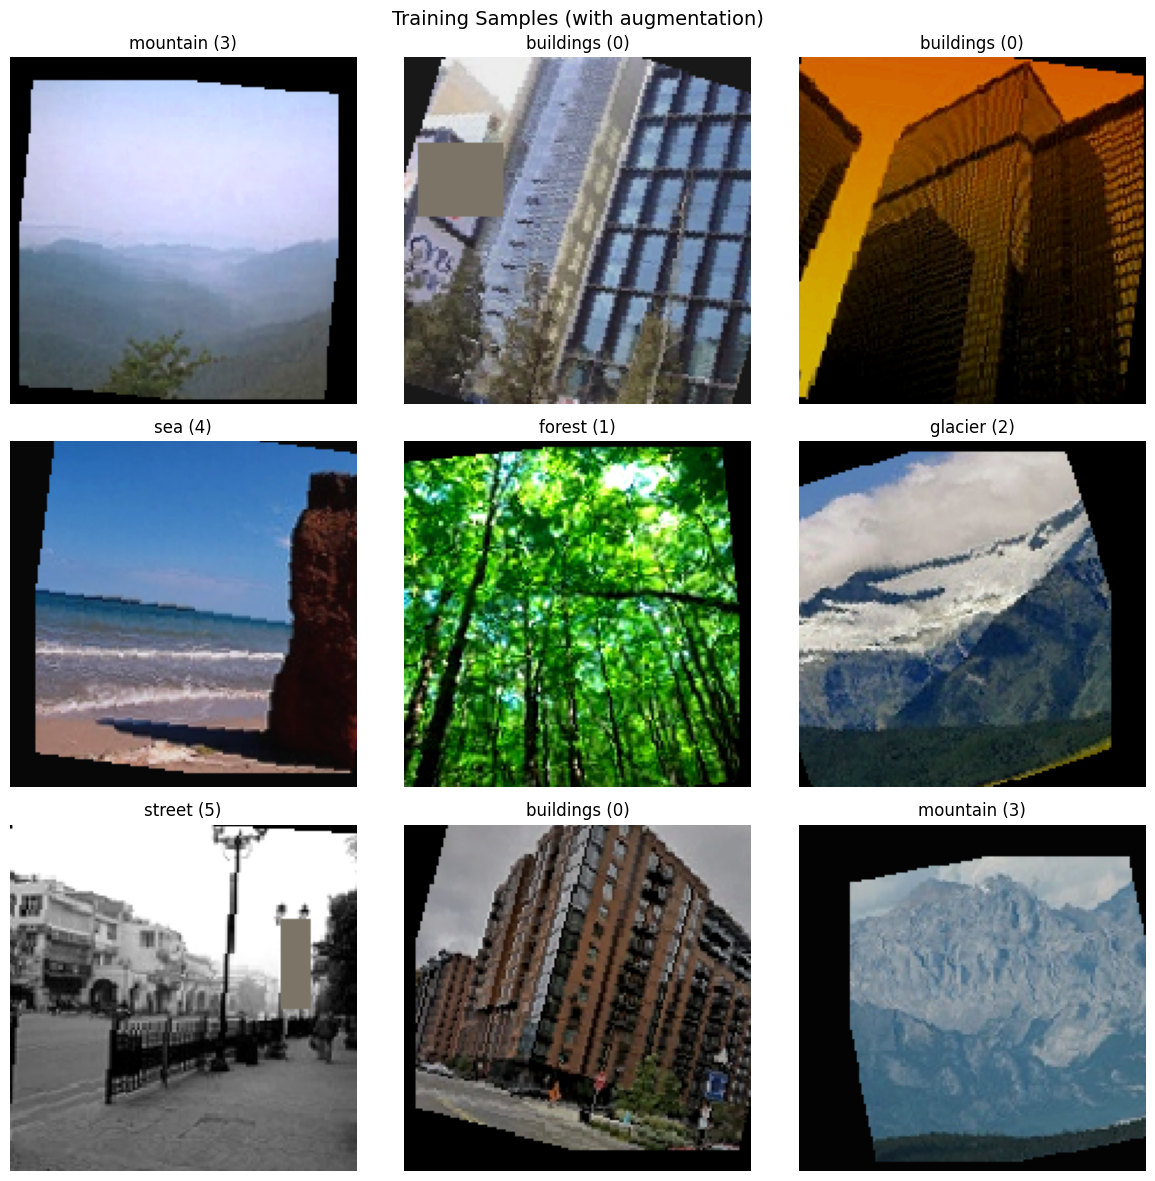

In [19]:
train_path = '/kaggle/input/intel-image-classification/seg_train/seg_train'

train_dataset = datasets.ImageFolder(root=train_path, transform=train_transform)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=2, pin_memory=True)

print(f"Training samples: {len(train_dataset)}")
print(f"Classes: {train_dataset.class_to_idx}")
print(f"Number of classes: {len(train_dataset.classes)}")

# Visualize samples
for images, labels in train_loader:
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    images_vis = images * std + mean
    images_vis = images_vis.clamp(0, 1)

    class_names = list(train_dataset.class_to_idx.keys())
    plt.figure(figsize=(12, 12))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images_vis[i].permute(1, 2, 0))
        plt.title(f"{class_names[labels[i].item()]} ({labels[i].item()})")
        plt.axis('off')
    plt.suptitle("Training Samples (with augmentation)", fontsize=14)
    plt.tight_layout()
    plt.show()
    break


### Load Validation and Test Datasets

Stratified 80/20 split of seg_test to maintain class balance.


In [20]:
val_path = '/kaggle/input/intel-image-classification/seg_test/seg_test'
val_dataset_full = datasets.ImageFolder(root=val_path, transform=eval_transform)

targets = np.array(val_dataset_full.targets)

# Stratified split: 80% validation, 20% test
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for val_idx, test_idx in splitter.split(np.zeros(len(targets)), targets):
    val_dataset = Subset(val_dataset_full, val_idx)
    test_dataset = Subset(val_dataset_full, test_idx)

val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False,
                        num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False,
                         num_workers=2, pin_memory=True)

print(f"Full seg_test samples: {len(val_dataset_full)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")


Full seg_test samples: 3000
Validation samples: 2400
Test samples: 600


### Load Competition Test Dataset (Unlabeled)

In [21]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Convert to grayscale
    transforms.Resize((150, 150)),                # Resize images to 150x150
    transforms.ToTensor(),                        # Convert images to tensors
    transforms.Normalize(mean=[0.5], std=[0.5])   # Normalize images to [0, 1]
])

In [22]:
# Step 1: List the images in the directory
image_directory = '/kaggle/input/intel-image-classification/seg_pred/seg_pred'
image_files = os.listdir(image_directory)

# Filter out only files with image extensions if necessary
image_files = [f for f in image_files if f.endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

# Step 2: Select the first 200 images
image_files = image_files[:200]

class SelectedFilesDataset(Dataset):
    def __init__(self, root_dir, file_names, transform=None):
        """
        Args:
            root_dir (str): Directory where files are stored.
            file_names (list): List of selected filenames (not full paths).
            transform (callable, optional): Transformations to apply to images.
        """
        self.root_dir = root_dir
        self.file_names = file_names
        self.transform = transform

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        file_path = os.path.join(self.root_dir, self.file_names[idx])
        image = Image.open(file_path).convert("RGB")  # Load image

        if self.transform:
            image = self.transform(image)

        return image, self.file_names[idx]  # Return image + filename

# Example usage

comp_test_dataset = SelectedFilesDataset(image_directory, image_files, transform = transform)
comp_test_loader = DataLoader(comp_test_dataset, batch_size=100, shuffle=False)

In [23]:
image_files

['6234.jpg',
 '22288.jpg',
 '20529.jpg',
 '21440.jpg',
 '5982.jpg',
 '7737.jpg',
 '2081.jpg',
 '10054.jpg',
 '3919.jpg',
 '21838.jpg',
 '6399.jpg',
 '9960.jpg',
 '3757.jpg',
 '9131.jpg',
 '9062.jpg',
 '4489.jpg',
 '3417.jpg',
 '6074.jpg',
 '7894.jpg',
 '10305.jpg',
 '4407.jpg',
 '17720.jpg',
 '15979.jpg',
 '8983.jpg',
 '9697.jpg',
 '21590.jpg',
 '2628.jpg',
 '22604.jpg',
 '16202.jpg',
 '3363.jpg',
 '13333.jpg',
 '14395.jpg',
 '6943.jpg',
 '3228.jpg',
 '12132.jpg',
 '8075.jpg',
 '6365.jpg',
 '6459.jpg',
 '7690.jpg',
 '21966.jpg',
 '23566.jpg',
 '13087.jpg',
 '4772.jpg',
 '21145.jpg',
 '6925.jpg',
 '10201.jpg',
 '15764.jpg',
 '7918.jpg',
 '16401.jpg',
 '20789.jpg',
 '11617.jpg',
 '23258.jpg',
 '19651.jpg',
 '6800.jpg',
 '14376.jpg',
 '20321.jpg',
 '12267.jpg',
 '18227.jpg',
 '4765.jpg',
 '22270.jpg',
 '21588.jpg',
 '6209.jpg',
 '5068.jpg',
 '11529.jpg',
 '6229.jpg',
 '1749.jpg',
 '15360.jpg',
 '1995.jpg',
 '24068.jpg',
 '18048.jpg',
 '12334.jpg',
 '20429.jpg',
 '3537.jpg',
 '21946.jpg',


## Step 2: Model Definition — Deep Residual MLP

### Architecture Design Philosophy
MLPs lack the spatial inductive bias of CNNs, so we compensate with:
- **Residual connections** in each block to enable deeper networks and better gradient flow
- **BatchNorm** after every linear layer for stable training
- **GELU activation** — smoother than ReLU, provides better gradient signal
- **Progressive dimensionality reduction** to learn hierarchical features
- **Aggressive dropout** (0.4-0.5) to prevent memorization of pixel positions

### Architecture:
```
Input: 3×150×150 = 67,500 (flattened)
  → Stem: Linear(67500 → 2048) + BN + GELU + Dropout(0.3)
  → ResBlock 1: 2048 → 2048 (with skip connection)
  → ResBlock 2: 2048 → 1024 (with projection skip)
  → ResBlock 3: 1024 → 512 (with projection skip)
  → ResBlock 4: 512 → 256 (with projection skip)
  → Head: Linear(256 → 6)
```

Each ResBlock: Linear → BN → GELU → Dropout → Linear → BN → + skip → GELU


In [24]:
class ResidualBlock(nn.Module):
    """MLP residual block with optional dimension change via projection."""
    def __init__(self, in_dim, out_dim, dropout=0.4):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(out_dim, out_dim),
            nn.BatchNorm1d(out_dim),
        )
        # Projection shortcut if dimensions differ
        self.skip = nn.Identity() if in_dim == out_dim else nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.BatchNorm1d(out_dim)
        )
        self.act = nn.GELU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout(self.act(self.block(x) + self.skip(x)))


class DeepResidualMLP(nn.Module):
    """
    Deep MLP with residual connections for image classification.
    Input: flattened RGB image (3 x 150 x 150 = 67,500)
    Output: 6-class logits
    """
    def __init__(self, input_dim=67500, n_classes=6):
        super().__init__()

        # Stem: project high-dimensional input to manageable size
        self.stem = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 2048),
            nn.BatchNorm1d(2048),
            nn.GELU(),
            nn.Dropout(0.3),
        )

        # Residual blocks with progressive reduction
        self.res_blocks = nn.Sequential(
            ResidualBlock(2048, 2048, dropout=0.4),
            ResidualBlock(2048, 1024, dropout=0.4),
            ResidualBlock(1024, 512,  dropout=0.4),
            ResidualBlock(512,  256,  dropout=0.3),
        )

        # Classification head
        self.head = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, n_classes)
        )

        # Weight initialization
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.res_blocks(x)
        x = self.head(x)
        return x


# Initialize model
n_features = 3 * 150 * 150  # RGB 150x150
net = DeepResidualMLP(input_dim=n_features, n_classes=6).to(device)
print(net)

# Count parameters
total_params = sum(p.numel() for p in net.parameters())
trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


DeepResidualMLP(
  (stem): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=67500, out_features=2048, bias=True)
    (2): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): GELU(approximate='none')
    (4): Dropout(p=0.3, inplace=False)
  )
  (res_blocks): Sequential(
    (0): ResidualBlock(
      (block): Sequential(
        (0): Linear(in_features=2048, out_features=2048, bias=True)
        (1): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.4, inplace=False)
        (4): Linear(in_features=2048, out_features=2048, bias=True)
        (5): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (skip): Identity()
      (act): GELU(approximate='none')
      (dropout): Dropout(p=0.4, inplace=False)
    )
    (1): ResidualBlock(
      (block): Sequential(
        (0): Linear(in_fe

## Step 3: Training Configuration

- **Loss:** CrossEntropyLoss with label smoothing (0.1) for better generalization
- **Optimizer:** AdamW (decoupled weight decay — better for regularization than L2 in Adam)
- **Scheduler:** CosineAnnealingWarmRestarts — cyclic LR for escaping local minima
- **Mixup:** α=0.2 — interpolates training pairs for smoother decision boundaries
- **Early stopping:** patience of 10 epochs on validation accuracy


In [25]:
# Loss function with label smoothing
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Optimizer: AdamW with decoupled weight decay
optimizer = optim.AdamW(net.parameters(), lr=1e-3, weight_decay=5e-4)

# Scheduler: Cosine annealing with warm restarts (T_0=10 epochs per cycle)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)

# Training configuration
num_epochs = 60
early_stop_patience = 10

# Mixup function
def mixup_data(x, y, alpha=0.2):
    """Applies Mixup augmentation to a batch."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Mixup loss: weighted combination of losses for both targets."""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print("Training configuration ready.")
print(f"  Epochs: {num_epochs}")
print(f"  Batch size: {batch_size}")
print(f"  Optimizer: AdamW (lr=1e-3, wd=5e-4)")
print(f"  Scheduler: CosineAnnealingWarmRestarts (T_0=10)")
print(f"  Label smoothing: 0.1")
print(f"  Mixup alpha: 0.2")
print(f"  Early stopping patience: {early_stop_patience}")


Training configuration ready.
  Epochs: 60
  Batch size: 64
  Optimizer: AdamW (lr=1e-3, wd=5e-4)
  Scheduler: CosineAnnealingWarmRestarts (T_0=10)
  Label smoothing: 0.1
  Mixup alpha: 0.2
  Early stopping patience: 10


## Step 4: Training Loop with Mixup, Validation, and Early Stopping

In [ ]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_acc = 0.0
best_model_state = None
epochs_no_improve = 0

for epoch in range(num_epochs):
    # ===== Training Phase =====
    net.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Apply Mixup
        mixed_images, targets_a, targets_b, lam = mixup_data(images, labels, alpha=0.2)

        # Forward pass (MLP expects flattened input)
        outputs = net(mixed_images)
        loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        # Gradient clipping to stabilize training
        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        # Track accuracy on original (non-mixed) predictions
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (lam * (predicted == targets_a).sum().item() +
                          (1 - lam) * (predicted == targets_b).sum().item())

    # Step scheduler
    scheduler.step(epoch + 1)

    train_loss = running_loss / total_train
    train_acc = correct_train / total_train
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ===== Validation Phase =====
    net.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss = val_loss / total_val
    val_acc = correct_val / total_val
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    current_lr = optimizer.param_groups[0]['lr']

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(net.state_dict())
        torch.save(net.state_dict(), 'best_model.pth')
        epochs_no_improve = 0
        marker = ' B'
    else:
        epochs_no_improve += 1
        marker = ''

    print(f"Epoch [{epoch+1:2d}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"LR: {current_lr:.6f}{marker}")

    # Early stopping
    if epochs_no_improve >= early_stop_patience:
        print(f"\n Early stopping at epoch {epoch+1} (no improvement for {early_stop_patience} epochs)")
        break

print(f"\n Best Validation Accuracy: {best_val_acc:.4f}")


Epoch [ 1/60] Train Loss: 1.6999 | Train Acc: 0.3357 | Val Loss: 1.4440 | Val Acc: 0.4771 | LR: 0.000976 B
Epoch [ 2/60] Train Loss: 1.5223 | Train Acc: 0.4370 | Val Loss: 1.3413 | Val Acc: 0.5329 | LR: 0.000905 B
Epoch [ 3/60] Train Loss: 1.4830 | Train Acc: 0.4587 | Val Loss: 1.3215 | Val Acc: 0.5308 | LR: 0.000794
Epoch [ 4/60] Train Loss: 1.4672 | Train Acc: 0.4701 | Val Loss: 1.3028 | Val Acc: 0.5487 | LR: 0.000655 B
Epoch [ 5/60] Train Loss: 1.4444 | Train Acc: 0.4807 | Val Loss: 1.2756 | Val Acc: 0.5579 | LR: 0.000501 B


### Training and Validation Curves

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(val_losses, label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Over Epochs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(train_accuracies, label='Train Acc', linewidth=2)
axes[1].plot(val_accuracies, label='Val Acc', linewidth=2, color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Over Epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Val accuracy with best marker
axes[2].plot(val_accuracies, label='Val Accuracy', linewidth=2, color='green')
axes[2].axhline(y=best_val_acc, color='red', linestyle='--', label=f'Best: {best_val_acc:.4f}')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Validation Accuracy with Best Marker')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 5: Test Set Evaluation (Sanity Check)

Load the best model and evaluate on the held-out test set.


In [ ]:
# Load best model
net.load_state_dict(best_model_state)
net.eval()

correct_test = 0
total_test = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = correct_test / total_test
print(f"Test Accuracy: {test_acc:.4f}")

# Per-class accuracy
class_names = list(train_dataset.class_to_idx.keys())
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print(f"\nPer-class accuracy:")
for i, name in enumerate(class_names):
    mask = all_labels == i
    if mask.sum() > 0:
        class_acc = (all_preds[mask] == all_labels[mask]).mean()
        print(f"  {name}: {class_acc:.4f} ({mask.sum()} samples)")


## Step 6: Generate Competition Predictions

In [ ]:
# Ensure best model is loaded
net.load_state_dict(best_model_state)
net.eval()

preds = []
ids = []

with torch.no_grad():
    for images, names in comp_test_loader:
        images = images.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        preds.extend(predicted.cpu().numpy().tolist())
        ids.extend(list(names))

# Create DataFrame and save CSV
df = pd.DataFrame({'id': ids, 'pred': preds})
csv_file = 'predictions.csv'
df.to_csv(csv_file, index=False)

print(f"CSV file '{csv_file}' created successfully.")
print(f"Total predictions: {len(df)}")
print(f"\nPrediction distribution:")
print(df['pred'].value_counts().sort_index())
print(f"\nFirst 10 rows:")
print(df.head(10))


## Done!
The `predictions.csv` file is saved and ready for submission to HuggingFace.

### Model Summary — Deep Residual MLP
| Aspect | Detail |
|--------|--------|
| Architecture | Deep Residual MLP (4 residual blocks) |
| Input | RGB 3ch, 150×150, flattened to 67,500 |
| Activations | GELU |
| Residual connections | Yes (with projection shortcuts) |
| Regularization | Dropout (0.2-0.4) + BatchNorm + Weight Decay (5e-4) + Label Smoothing (0.1) + Mixup (α=0.2) + RandomErasing |
| Optimizer | AdamW (lr=1e-3, wd=5e-4) |
| Scheduler | CosineAnnealingWarmRestarts (T_0=10, T_mult=2) |
| Augmentation | RandomCrop, HFlip, Rotation, Affine, ColorJitter, RandomErasing |
| Gradient clipping | max_norm=1.0 |
| Early stopping | patience=10 on val accuracy |
